# Liver Disease Detection using Machine Learning

# Exploratory Data Analysis (EDA)

Dataset: Indian Liver Patient Dataset (ILPD)

## Objective
To understand the dataset using statistical analysis and visualization before training machine learning models.

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [13]:
df = pd.read_csv("../dataset/preprocessed_liver_data.csv")

In [14]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,1.241741,-1.752549,-0.418647,-0.493702,-0.427421,-0.351482,-0.314428,0.279290,0.189737,-0.150447,1
1,1.056874,0.570597,1.210111,1.413923,1.661722,-0.086746,-0.032278,0.923059,0.064127,-0.653221,1
2,1.056874,0.570597,0.635255,0.919354,0.808927,-0.108807,-0.142385,0.463224,0.189737,-0.181870,1
3,0.810385,0.570597,-0.370743,-0.387723,-0.447823,-0.362513,-0.307546,0.279290,0.315348,0.163788,1
4,1.673096,0.570597,0.092336,0.177500,-0.394778,-0.290813,-0.173353,0.739125,-0.940754,-1.721618,1


In [15]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])


Number of Rows : 570
Number of Columns : 11


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         570 non-null    float64
 1   Gender                      570 non-null    float64
 2   Total_Bilirubin             570 non-null    float64
 3   Direct_Bilirubin            570 non-null    float64
 4   Alkaline_Phosphotase        570 non-null    float64
 5   Alamine_Aminotransferase    570 non-null    float64
 6   Aspartate_Aminotransferase  570 non-null    float64
 7   Total_Protiens              570 non-null    float64
 8   Albumin                     570 non-null    float64
 9   Albumin_and_Globulin_Ratio  570 non-null    float64
 10  Dataset                     570 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 49.1 KB


In [17]:
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,5.700000e+02,570.000000
mean,1.246566e-17,-3.739699e-17,4.674623e-18,3.116416e-17,7.479397e-17,-1.869849e-17,1.246566e-17,-4.487638e-16,-3.864355e-16,1.542626e-16,1.287719
std,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,1.000878e+00,0.453097
min,-2.517211e+00,-1.752549e+00,-4.665521e-01,-4.937018e-01,-9.333852e-01,-3.845741e-01,-3.419546e-01,-3.491362e+00,-2.824907e+00,-2.035852e+00,1.000000
25%,-7.301685e-01,5.705974e-01,-4.026792e-01,-4.583754e-01,-4.723049e-01,-3.128747e-01,-2.903418e-01,-6.403815e-01,-6.895338e-01,-7.789149e-01,1.000000
50%,9.297379e-03,5.705974e-01,-3.707428e-01,-4.230490e-01,-3.417335e-01,-2.466906e-01,-2.352881e-01,9.535537e-02,-6.148288e-02,-5.617626e-02,1.000000
75%,8.103855e-01,5.705974e-01,-1.152513e-01,-6.978512e-02,2.549865e-02,-1.088070e-01,-7.786897e-02,6.471580e-01,8.177884e-01,4.780219e-01,2.000000
max,2.782295e+00,5.705974e-01,1.144574e+01,6.430271e+00,7.419106e+00,1.059096e+01,1.658361e+01,2.854369e+00,2.953162e+00,5.820003e+00,2.000000


In [18]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

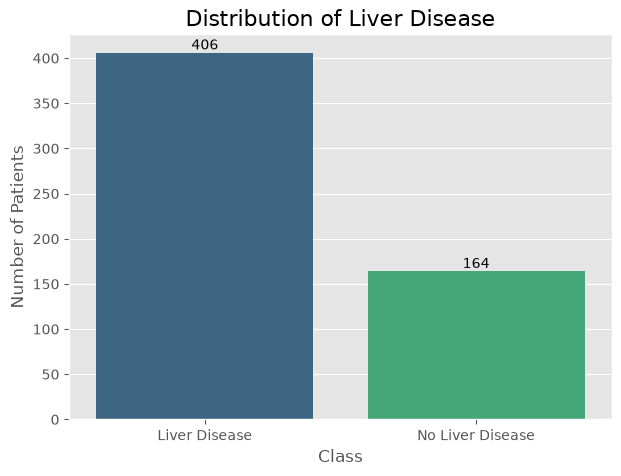

In [21]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x="Dataset", data=df, palette="viridis")

plt.title("Distribution of Liver Disease", fontsize=16)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Rename class labels
ax.set_xticklabels(["Liver Disease", "No Liver Disease"])

# Display count on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()


### Observation

The dataset is imbalanced.

Patients with liver disease are more than patients without liver disease.

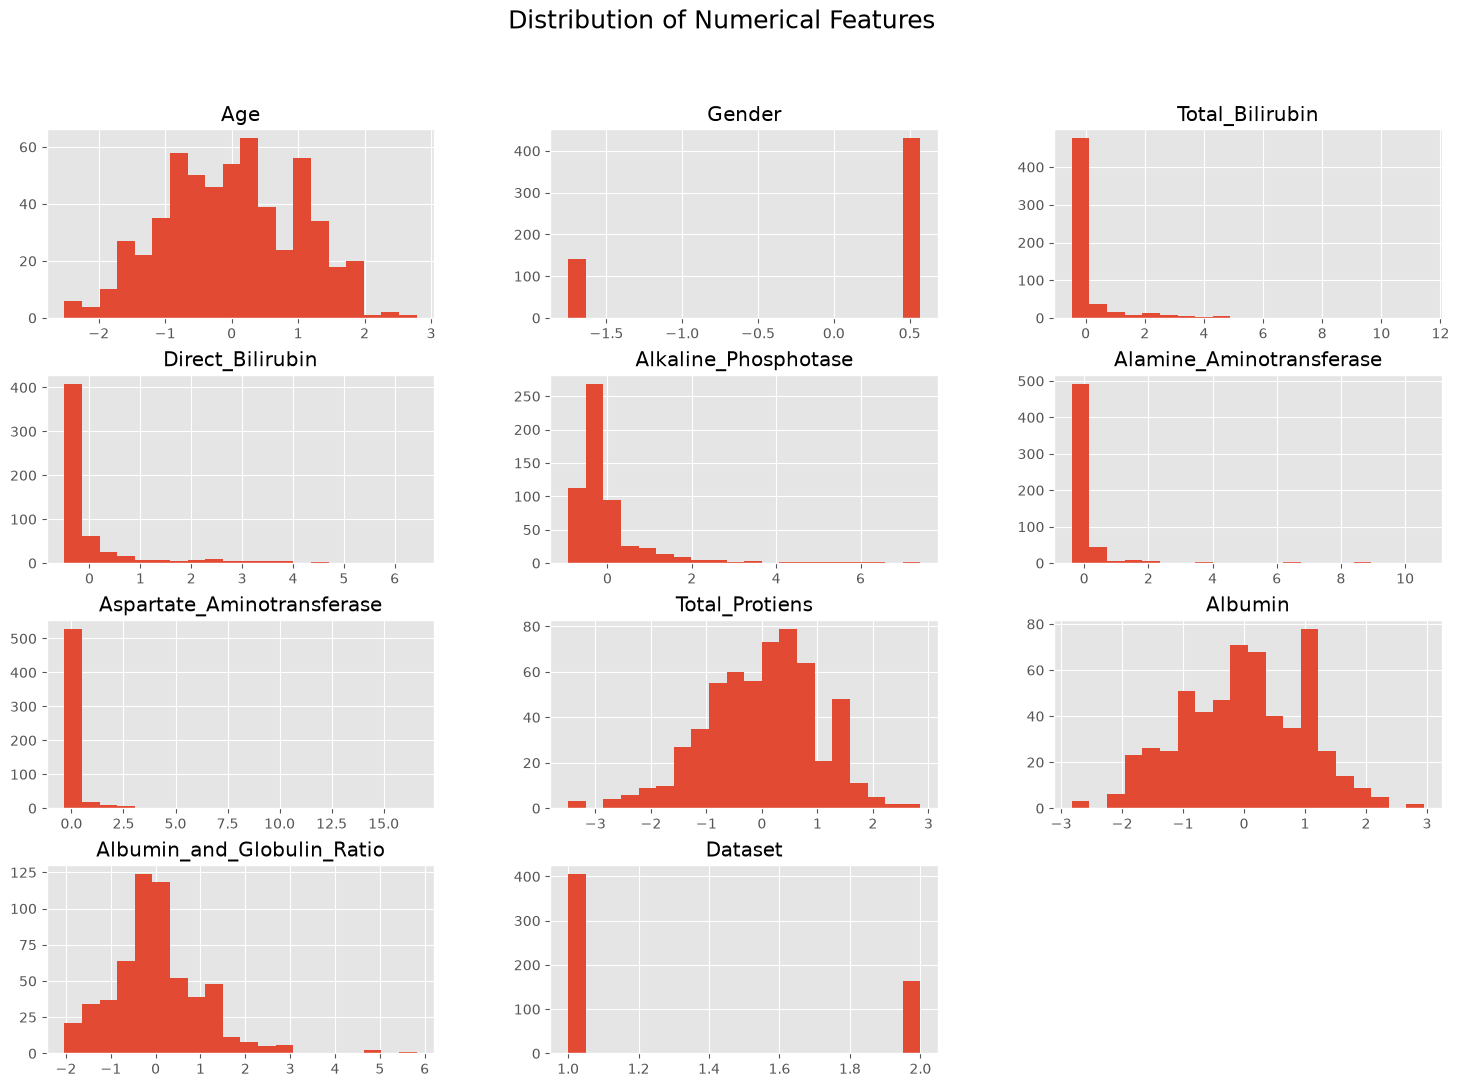

In [22]:
df.hist(figsize=(18,12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.show()

## Observation

- Most features are positively skewed.
- Few features follow a normal distribution.
- Some features contain extreme values (outliers).

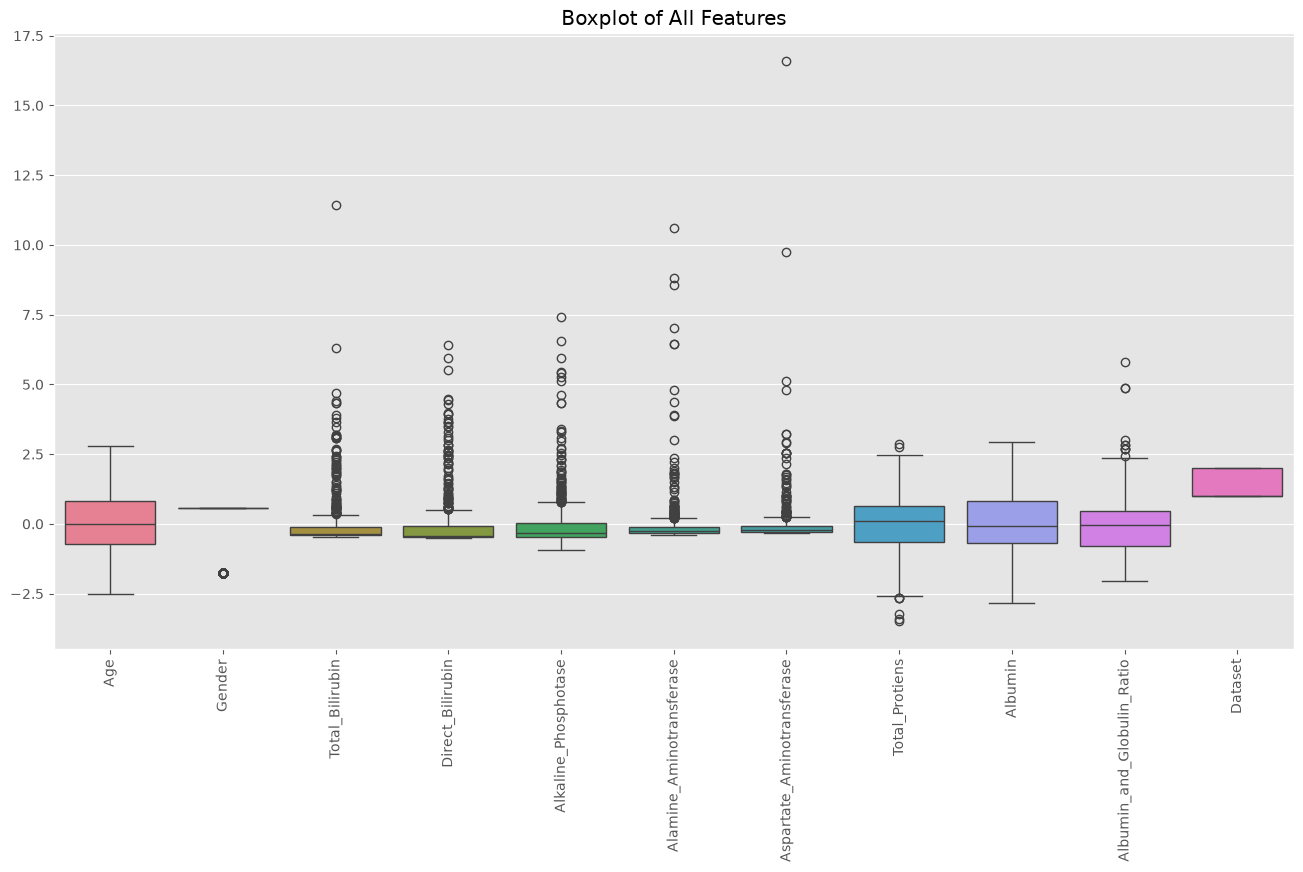

In [23]:
plt.figure(figsize=(16,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplot of All Features")

plt.show()

## Observation

- Several numerical features contain outliers.
- Outliers are expected in medical datasets and may represent genuine patient conditions.

In [24]:
correlation = df.corr()

correlation

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
Age,1.000000,0.058237,0.011500,0.007050,0.081673,-0.083383,-0.016753,-0.197052,-0.271170,-0.215506,-0.138093
Gender,0.058237,1.000000,0.090298,0.101730,-0.023014,0.084317,0.081497,-0.085895,-0.091369,-0.005343,-0.078501
Total_Bilirubin,0.011500,0.090298,1.000000,0.874116,0.206239,0.217471,0.238678,-0.008588,-0.224124,-0.207474,-0.224430
Direct_Bilirubin,0.007050,0.101730,0.874116,1.000000,0.234609,0.237450,0.258489,-0.000875,-0.230751,-0.201228,-0.250666
Alkaline_Phosphotase,0.081673,-0.023014,0.206239,0.234609,1.000000,0.126830,0.167230,-0.030048,-0.168318,-0.235848,-0.187560
Alamine_Aminotransferase,-0.083383,0.084317,0.217471,0.237450,0.126830,1.000000,0.791857,-0.035193,-0.027973,-0.006394,-0.161917
Aspartate_Aminotransferase,-0.016753,0.081497,0.238678,0.258489,0.167230,0.791857,1.000000,-0.022000,-0.085180,-0.072783,-0.151101
Total_Protiens,-0.197052,-0.085895,-0.008588,-0.000875,-0.030048,-0.035193,-0.022000,1.000000,0.784731,0.233503,0.037794
Albumin,-0.271170,-0.091369,-0.224124,-0.230751,-0.168318,-0.027973,-0.085180,0.784731,1.000000,0.683854,0.166835
Albumin_and_Globulin_Ratio,-0.215506,-0.005343,-0.207474,-0.201228,-0.235848,-0.006394,-0.072783,0.233503,0.683854,1.000000,0.170345


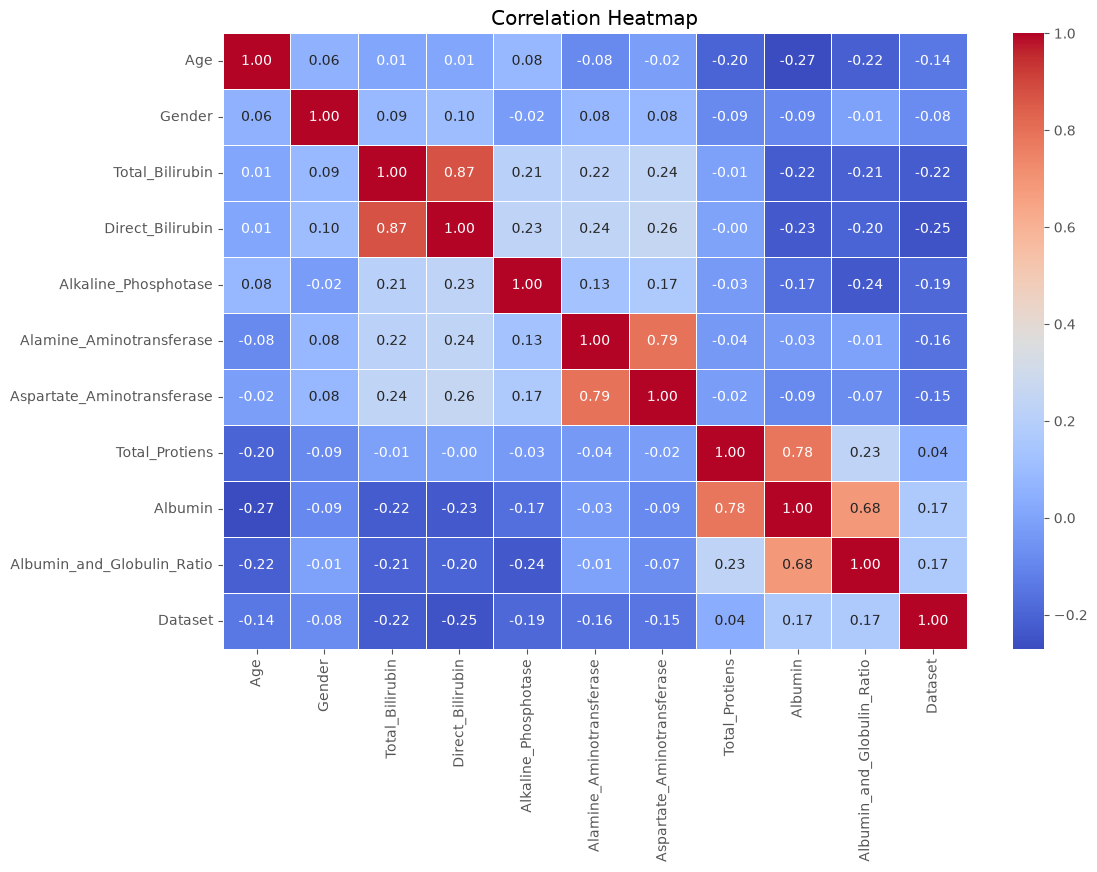

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- Some medical parameters show a strong positive correlation.
- Albumin and Albumin/Globulin Ratio are positively correlated.
- Total Bilirubin and Direct Bilirubin also show a positive correlation.
- Correlation analysis helps identify important features for model training.

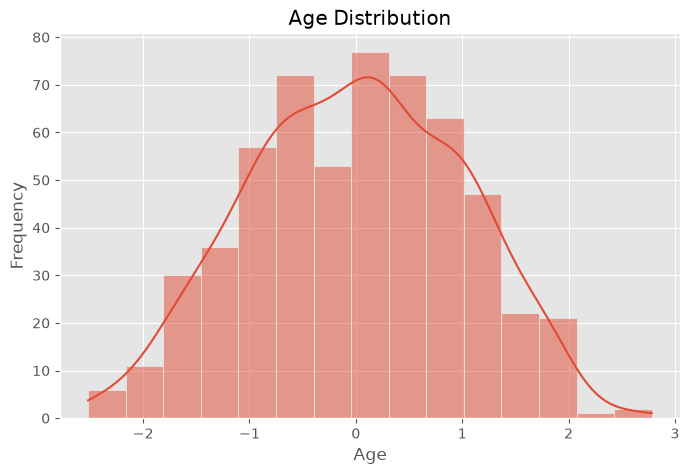

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

## Observation

- Most patients are middle-aged.
- Age is slightly positively skewed.

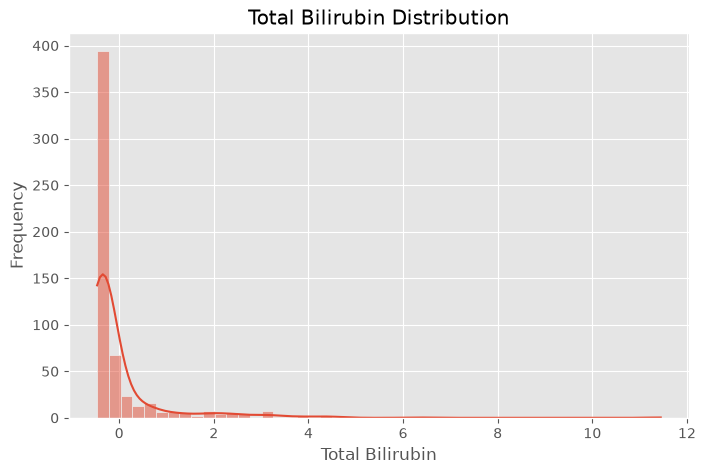

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total_Bilirubin'], kde=True)

plt.title("Total Bilirubin Distribution")

plt.xlabel("Total Bilirubin")

plt.ylabel("Frequency")

plt.show()

## Observation

- Most patients have low bilirubin values.
- A few patients have very high bilirubin levels.
- The feature is positively skewed.

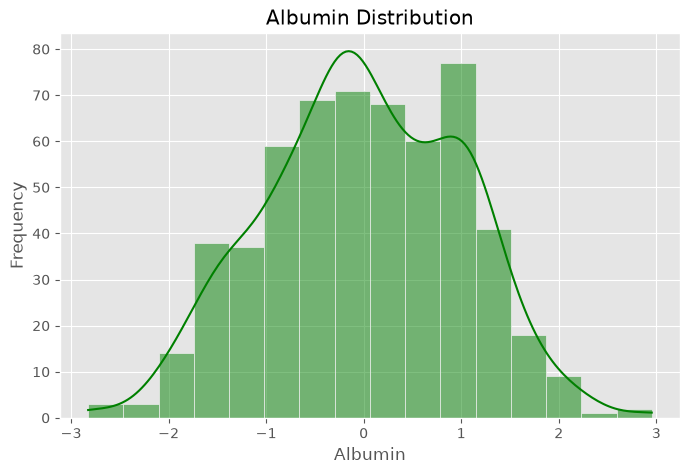

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['Albumin'], kde=True, color='green')

plt.title("Albumin Distribution")
plt.xlabel("Albumin")
plt.ylabel("Frequency")

plt.show()

## Observation

- Most patients have Albumin values between 2 and 4.
- The feature is slightly right-skewed.

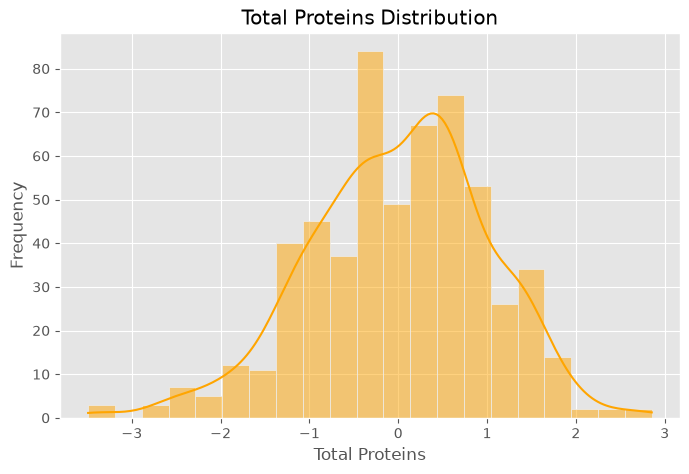

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total_Protiens'], kde=True, color='orange')

plt.title("Total Proteins Distribution")
plt.xlabel("Total Proteins")
plt.ylabel("Frequency")

plt.show()

## Observation

- Total Protein values are concentrated around the middle range.
- Very few patients have extremely high or low values.

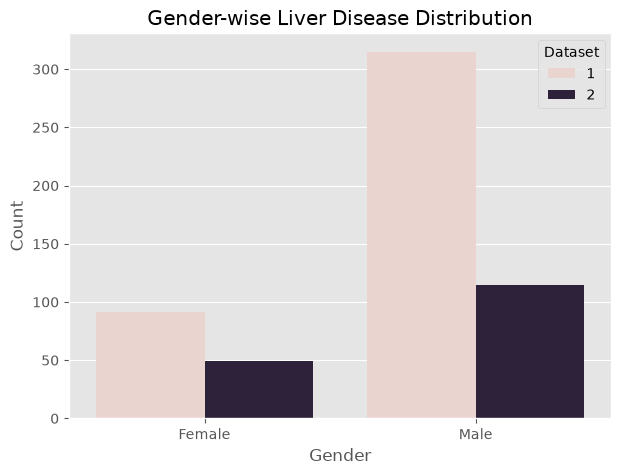

In [30]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Gender', hue='Dataset', data=df)

plt.title("Gender-wise Liver Disease Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

ax.set_xticklabels(['Female','Male'])

plt.show()

## Observation

- Male patients are more affected than female patients.
- The dataset contains more male records.

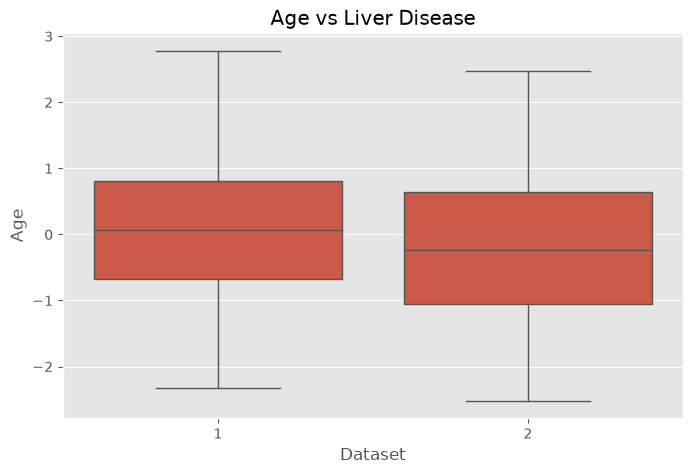

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Dataset', y='Age', data=df)

plt.title("Age vs Liver Disease")

plt.show()

## Observation

- Liver disease is observed across different age groups.
- Middle-aged patients appear more frequently.

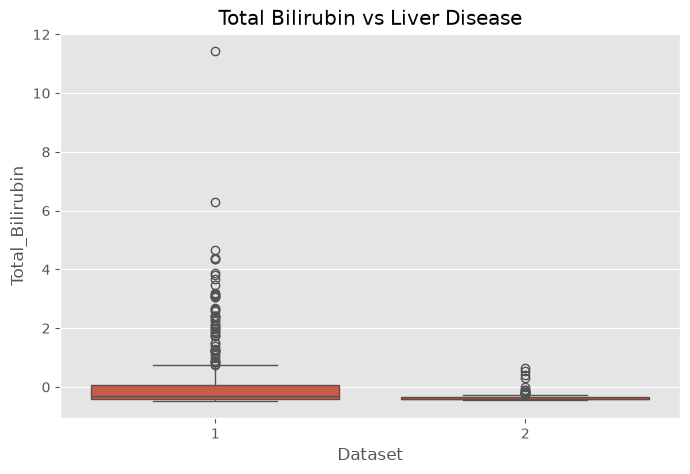

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Dataset', y='Total_Bilirubin', data=df)

plt.title("Total Bilirubin vs Liver Disease")

plt.show()

## Observation

- Patients with liver disease generally have higher bilirubin levels.
- Bilirubin appears to be an important predictor.

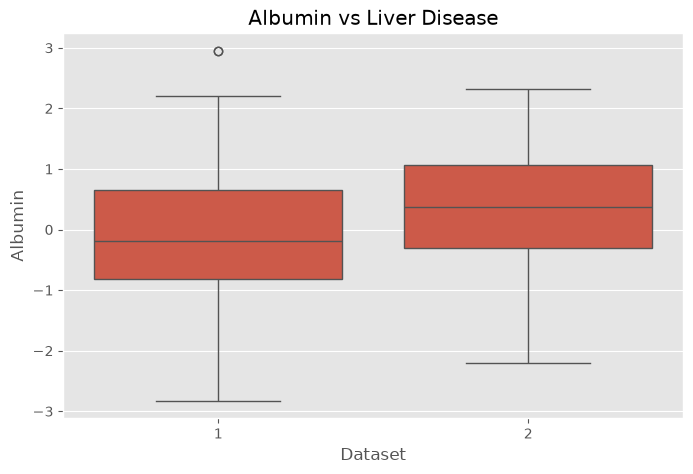

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Dataset', y='Albumin', data=df)

plt.title("Albumin vs Liver Disease")

plt.show()

## Observation

- Albumin values differ between the two classes.
- Albumin may contribute to prediction accuracy.

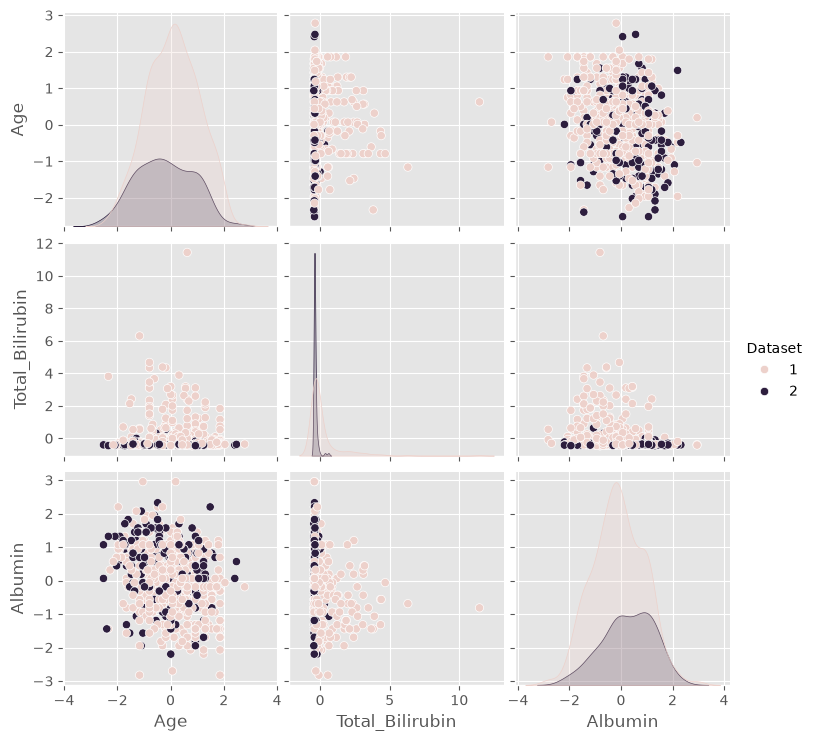

In [34]:
sns.pairplot(
    df[['Age',
        'Total_Bilirubin',
        'Albumin',
        'Dataset']],
    hue='Dataset'
)

plt.show()

## Observation

- Pairplot helps visualize relationships between important features.
- Some separation between the two target classes can be observed.

# Final EDA Conclusion

### Key Findings

- The dataset contains 570 patient records after removing duplicate entries.
- Missing values were successfully handled during preprocessing.
- The dataset is imbalanced, with more liver disease cases than non-liver disease cases.
- Most numerical features are positively skewed.
- Several numerical features contain outliers, which are common in medical datasets.
- Total Bilirubin and Direct Bilirubin show a strong positive correlation.
- Albumin and Albumin/Globulin Ratio are also positively correlated.
- Male patients are more represented in the dataset.
- Bilirubin and Albumin appear to be important features for liver disease prediction.

### Conclusion

The dataset is now fully explored and ready for machine learning model development.